# Anàlisi Exploratòria de Dades (EDA)
## Predicció de preus d'Airbnb a Mallorca

Aquest *notebook* té com a **objectiu** explorar el conjunt de dades resultant del procés de neteja i *feature engineering* (`listings_step5.csv`) per tal de:

- Comprendre la distribució i naturalesa de la variable objectiu (`price`).
- Detectar patrons, anomalies i relacions entre variables.
- Identificar possibles problemes (valors extrems, multicol·linealitat, variables amb renou).

Les dades d'entrada han passat per 5 etapes prèvies:
1. Tria de variables
2. Canvi de tipus de les variables
3. Transformació de les categories
4. Tractament dels valors nuls
5. *Feature engineering* (distàncies, índexs, variables de barri)

In [21]:
# =========================================================
# IMPORTS I CONFIGURACIÓ DE L'ENTORN
# =========================================================

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Estil de les gràfiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10


INPUT_CSV = "../data/data_cleaning/listings_step5.csv"
OUTPUTS_DIR = Path("../outputs")

def save_fig(fig, filename):
    """
    Guarda una figura al directori d'outputs en format .pdf
    """
    filepath = OUTPUTS_DIR / filename
    fig.savefig(filepath, bbox_inches='tight')  # sense dpi per vectorials
    print(f"   Figura guardada: {filepath.name}")

## 1. Càrrega de dades i visió general

Carreguem el CSV resultant i fem una primera ullada a la seva estructura: mida, tipus de variables i ús de memòria.

In [22]:
# Carregar el dataset
df = pd.read_csv(INPUT_CSV)

# Reconvertir les columnes de data (el CSV les desa com a string)
datetime_cols = [c for c in ['host_since', 'first_review', 'last_review'] if c in df.columns]
for c in datetime_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

print(f"Files     : {df.shape[0]}")
print(f"Columnes  : {df.shape[1]}")
print(f"Memòria   : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()

# Primeres files
df.head(3)

Files     : 14342
Columnes  : 71
Memòria   : 4.93 MB



,id,host_id,host_since,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,has_reviews,dist_sea_km,dist_sea_squared_km,dist_sea_log_km,dist_palma_center_km,dist_airport_km,amenity_index,num_listings_neighborhood,avg_price_neighborhood,price_ratio_vs_neighborhood
0,69998,353156,2011-01-19,1.0,1.00,False,3.0,True,True,Palma de Mallorca,...,True,0.655363,0.429501,-0.407422,0.382694,7.508654,10,1043,528.809204,0.310131
1,106833,551974,2011-05-02,1.0,0.86,False,1.0,True,True,Sant Llorenç des Cardassar,...,True,7.439303,55.343228,2.008120,56.126083,48.800945,4,261,1953.329502,0.102389
2,159218,763897,2011-06-30,1.0,1.00,True,2.0,True,True,Selva,...,True,9.480632,89.882378,2.250305,33.176940,30.388186,8,230,1352.286957,0.118318


In [23]:
# Classificació de variables per tipus
dtype_summary = df.dtypes.value_counts().rename('count').to_frame()
print("Tipus de variables:")
print(dtype_summary)
print()

# Llistat complet de columnes ordenades alfabèticament
print(f"Columnes del dataset ({len(df.columns)}):")
for i, col in enumerate(sorted(df.columns), 1):
    print(f"  {i:>2}. {col}")

Tipus de variables:
                count
bool               31
float64            24
int64              12
datetime64[us]      3
str                 1

Columnes del dataset (71):
   1. accommodates
   2. amenity_bed_linens
   3. amenity_dishes_and_silverware
   4. amenity_essentials
   5. amenity_hair_dryer
   6. amenity_index
   7. amenity_iron
   8. amenity_kitchen
   9. amenity_microwave
  10. amenity_refrigerator
  11. amenity_washer
  12. amenity_wifi
  13. availability_30
  14. availability_365
  15. avg_price_neighborhood
  16. bathrooms
  17. bedrooms
  18. beds
  19. dist_airport_km
  20. dist_palma_center_km
  21. dist_sea_km
  22. dist_sea_log_km
  23. dist_sea_squared_km
  24. estimated_occupancy_l365d
  25. estimated_revenue_l365d
  26. first_review
  27. has_availability
  28. has_license
  29. has_reviews
  30. host_acceptance_rate
  31. host_has_profile_pic
  32. host_id
  33. host_identity_verified
  34. host_is_superhost
  35. host_listings_count
  36. host_response_

## 2. Variable objectiu: `price`

Analitzem la distribució del preu que és la nostra variable objectiu.

In [24]:
# Estadístiques descriptives del preu
price = df['price']

stats = pd.Series({
    'count': price.count(),
    'mean': price.mean(),
    'std': price.std(),
    'min': price.min(),
    'Q1 (25%)': price.quantile(0.25),
    'median': price.median(),
    'Q3 (75%)': price.quantile(0.75),
    'max': price.max(),
    'skewness': price.skew(),
    'kurtosis': price.kurtosis(),
})
print("Estadístiques de price (EUR/vespre):")
print(stats.round(2))

Estadístiques de price (EUR/vespre):
count       14342.00
mean         1557.74
std          3106.60
min            10.00
Q1 (25%)      170.00
median        275.00
Q3 (75%)      527.75
max         10053.00
skewness        2.10
kurtosis        2.52
dtype: float64


   Figura guardada: eda_01_price_distribution.pdf


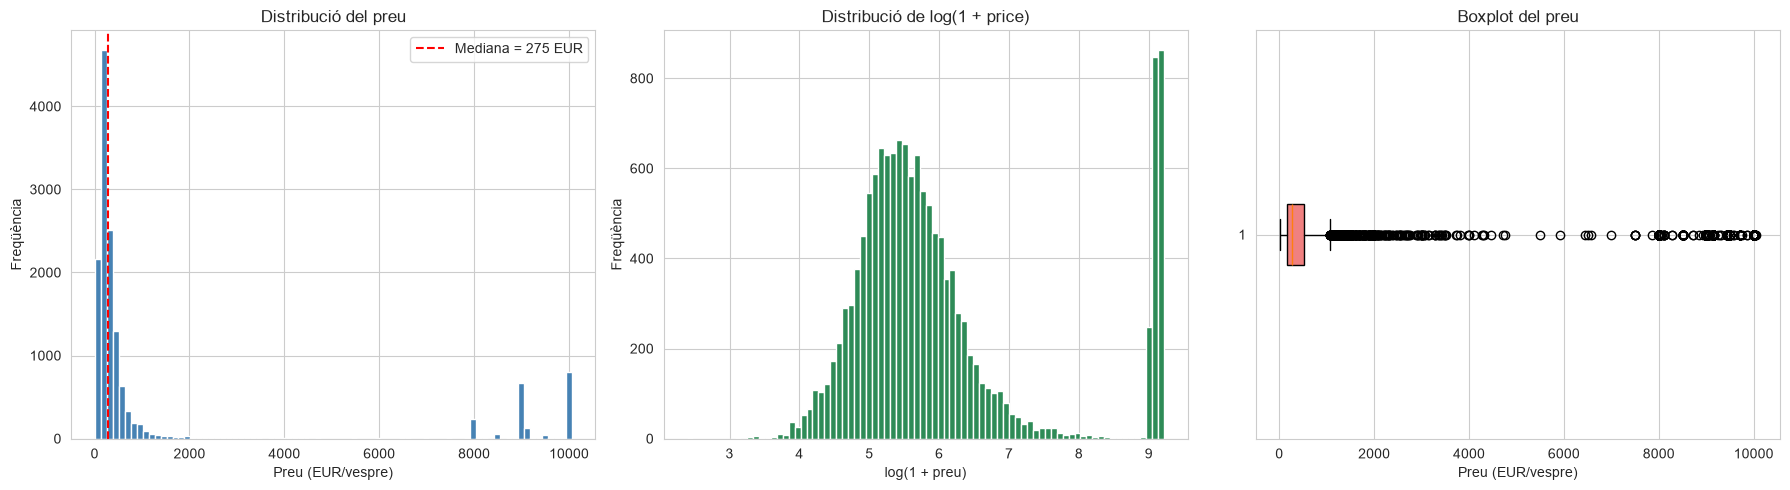

In [25]:
# Distribucions del preu
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma original
axes[0].hist(price, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribució del preu')
axes[0].set_xlabel('Preu (EUR/vespre)')
axes[0].set_ylabel('Freqüència')
axes[0].axvline(price.median(), color='red', linestyle='--',
                label=f'Mediana = {price.median():.0f} EUR')
axes[0].legend()

# 2. Histograma en escala logarítmica
log_price = np.log1p(price)
axes[1].hist(log_price, bins=80, color='seagreen', edgecolor='white')
axes[1].set_title('Distribució de log(1 + price)')
axes[1].set_xlabel('log(1 + preu)')
axes[1].set_ylabel('Freqüència')

# 3. Boxplot per detectar valors extrems
axes[2].boxplot(price, vert=False, patch_artist=True,
                boxprops={'facecolor': 'lightcoral'})
axes[2].set_title('Boxplot del preu')
axes[2].set_xlabel('Preu (EUR/vespre)')

plt.tight_layout()
save_fig(fig, 'eda_01_price_distribution.pdf')
plt.show()

In [26]:
# Detecció de valors extrems pel mètode IQR
Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(price < lower) | (price > upper)]
pct_iqr = len(outliers_iqr) / len(df) * 100

print(f"Rang IQR: [{lower:.2f}, {upper:.2f}] EUR")
print(f"Outliers (IQR): {len(outliers_iqr)} ({pct_iqr:.2f}%)")
print()

# Percentils alts
for p in [0.90, 0.95, 0.99, 0.995, 0.999]:
    print(f"   Percentil {p*100:>5.1f}%: {price.quantile(p):>10.2f} EUR")

print()
print(f"Preu màxim: {price.max():.2f} EUR")
print(f"Top 5 preus: {sorted(price.nlargest(5).values, reverse=True)}")

Rang IQR: [-366.62, 1064.38] EUR
Outliers (IQR): 2324 (16.20%)

   Percentil  90.0%:    9000.00 EUR
   Percentil  95.0%:    9999.00 EUR
   Percentil  99.0%:   10000.00 EUR
   Percentil  99.5%:   10000.00 EUR
   Percentil  99.9%:   10013.00 EUR

Preu màxim: 10053.00 EUR
Top 5 preus: [np.float64(10053.0), np.float64(10036.0), np.float64(10036.0), np.float64(10032.0), np.float64(10031.0)]


### Observacions sobre la variable objectiu

La variable objectiu `price` (preu per vespre en euros) presenta una distribució **fortament asimètrica cap a la dreta**, tal com, pel que he vist, és habitual en dades de preus d'allotjaments turístics:

#### Estadístiques descriptives

| Mètrica | Valor | Comentari |
|---|---|---|
| Mitjana | **1.557,74 €** | Molt allunyada de la mediana |
| Mediana | **275,00 €** | Valor representatiu del que paga un client |
| Desviació estàndard | **3.106,60 €** | És superior a la mitjana, indica una dispersió alta |
| Mínim | 10,00 € | Preu que cal validar |
| Màxim | 10.053,00 € | Clarament extrem per a un vespre |
| Asimetria (*skewness*) | **2,10** | Asimetria positiva moderada-alta |
| Curtosi | 2,52 | Cues més pesades que una normal |

La mitjana **no** és una bona mesura de tendència central per a aquesta variable. Qualsevol model que optimitzi $MAE$ o $MSE$ directament sobre `price` estarà dominat pels valors alts.

#### Valors extrems

Aplicant el criteri IQR:

- Rang: `[-366,62 €, 1.064,38 €]`
    - Fita inferior: $Q_1 - 1.5 \cdot IQR$ 
    - Fita superior: $Q_3 + 1.5 \cdot IQR$ 
    - $IQR = Q_3 - Q_1$
- **Outliers detectats: 2.324 (16,20%)** que és una proporció molt elevada.

Però aquí hi ha una troballa important que va més enllà dels outliers "naturals":

| Percentil | Valor |
|---|---|
| 90% | **9.000 €** |
| 95% | 9.999 € |
| 99% | 10.000 € |
| 99,5% | 10.000 € |
| 99,9% | 10.013 € |

**Els percentils 95-99,5 tendeixen a 10 000 €**, això indica que no es tracta de valors extrems "naturals", sinó d'un **pic artificial a la vora dels 10 000 €**. L'explicació més coherent és que és una fita superior del preu per part de la plataforma.

Al boxplot es veu clarament un núvol dens de punts concentrat al voltant de 9 000-10 000 €, separat de la caixa principal. L'histograma de `log(1+price)` també mostra un **pic a l'extrem dret** (`log ≈ 9,2`), la qual cosa ens diu que la transformació logarítmica **no aconsegueix normalitzar del tot** la distribució.

#### Implicacions per a la modelització

D'aquesta anàlisi es desprenen diverses decisions metodològiques:

1. Transformació de la variable objectiu a `log(price)` ja que suavitza molt la distribució principal.
2. Tractament dels valors extrems
   - **Filtrar** els allotjaments amb `price > 1.500 €/nit` (o una fita similar) i justificar-ho com a **valors no representatius del mercat de lloguer vacacional**.
   - **Winsoritzar** (capar) els preus al percentil 99 o 99,5.
   - **Mantenir-los** i emprar una funció de pèrdua robusta (per exemple, Huber loss o MAE en lloc de MSE).
   - Val la pena **investigar els 200-300 allotjaments amb `price > 5.000 €`**: comprovar si comparteixen `neighbourhood_cleansed`, `room_type` o algun patró (per exemple, tots de la mateixa zona o del mateix host). Si formen un grup homogeni, és probable que siguin un problema de les dades i s'hagin d'excloure.
3. Mètrica d'avaluació

   Com que la distribució de `price` és fortament asimètrica (asimetria = 2,10) i conté valors extrems fins a 10.053 €. A continuació s'expliquen les principals.

    - **MAE (*Mean Absolute Error*)**

        $$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$

        Mesura l'error absolut mitjà, en les mateixes unitats que $y$. És robust als valors extrems perquè no eleva els errors al quadrat. S'interpreta directament com "de mitjana, el model s'equivoca X €". El seu desavantatge és que penalitza igual un error de 50 € sobre un allotjament de 100 € que sobre un de 1.000 €, cosa que no reflecteix la realitat del mercat.

    - **RMSE (*Root Mean Squared Error*)**

        $$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

        És l'arrel de l'error quadràtic mitjà, també en les mateixes unitats que $y$. Penalitza molt més els errors grans que el MAE. Sempre es compleix $\text{RMSE} \geq \text{MAE}$, i com més gran és la diferència entre totes dues, més pes tenen els valors extrems en el resultat. 

## 4. Anàlisi de variables numèriques

Explorem les principals variables numèriques del dataset per entendre el perfil dels allotjaments.

In [27]:
# Identifiquem columnes per tipus

bool_cols = [c for c in df.columns if df[c].dtype == bool]
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns]

# Resum estadístic de les variables numèriques
num_summary = df[numeric_cols].describe().T
num_summary['skew'] = df[numeric_cols].skew()
num_summary = num_summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew']]
print(num_summary.round(2).to_string())

                               count          mean           std       min          25%           50%           75%           max   skew
id                           14342.0  5.299530e+17  5.842955e+17  69998.00  28550477.75  5.313962e+07  1.117406e+18  1.513880e+18   0.38
host_id                      14342.0  2.066953e+08  2.022432e+08  18651.00  50085123.25  1.210257e+08  3.404667e+08  7.177461e+08   0.98
host_response_rate           14342.0  9.700000e-01  1.100000e-01      0.00         0.99  1.000000e+00  1.000000e+00  1.000000e+00  -6.14
host_acceptance_rate         14342.0  9.300000e-01  1.600000e-01      0.00         0.96  9.900000e-01  1.000000e+00  1.000000e+00  -3.65
host_listings_count          14342.0  2.017600e+02  3.424000e+02      1.00         3.00  3.500000e+01  2.420000e+02  1.564000e+03   2.13
latitude                     14342.0  3.966000e+01  1.800000e-01     39.30        39.54  3.969000e+01  3.982000e+01  3.993000e+01  -0.33
longitude                    14342.0  3.0

   Figura guardada: eda_02_capacity_distributions.pdf


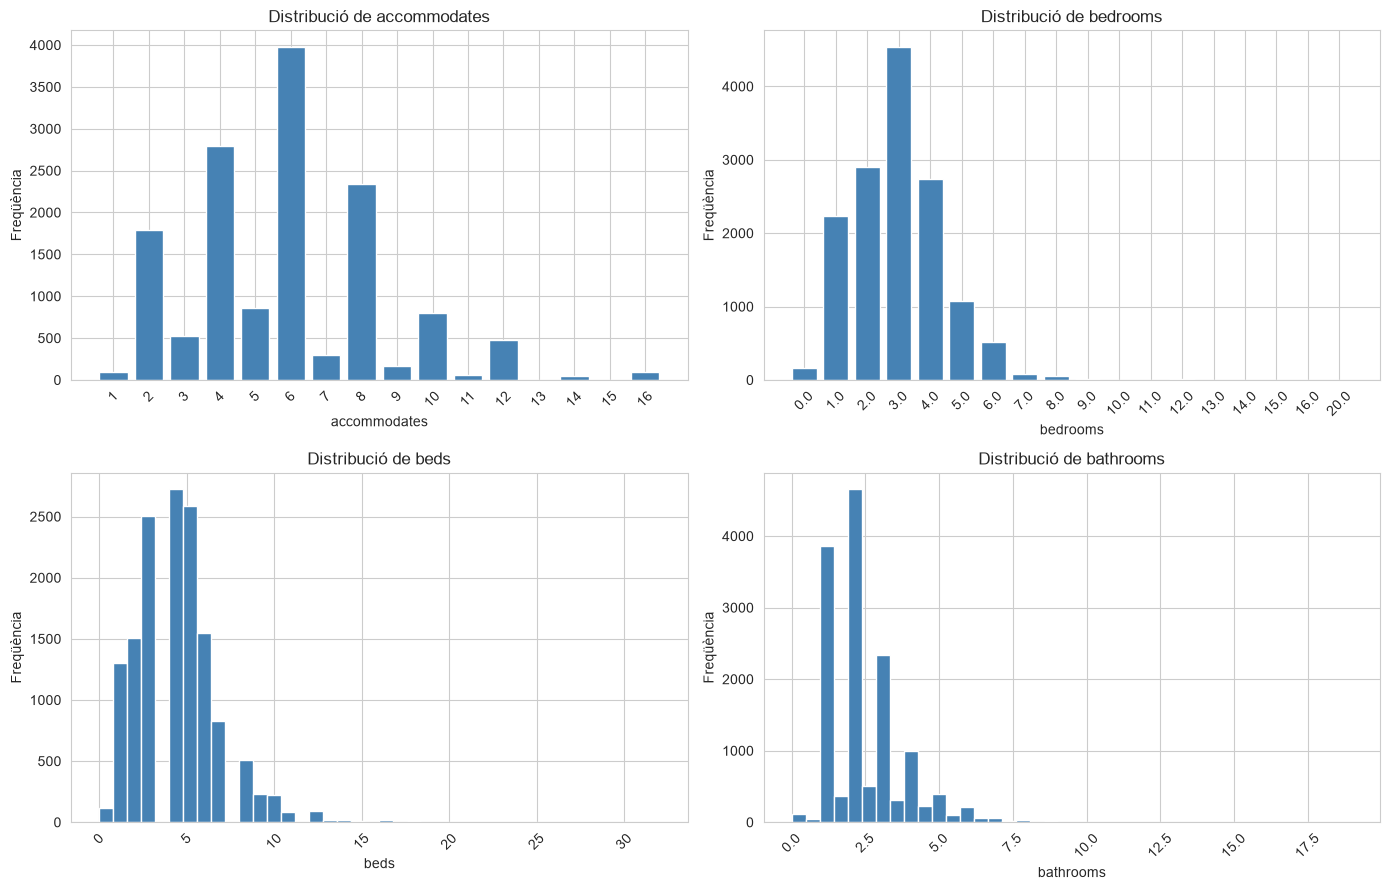

In [28]:
# Distribucions de les variables de capacitat i mida
capacity_vars = [c for c in ['accommodates', 'bedrooms', 'beds', 'bathrooms'] if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, capacity_vars):
    data = df[col].dropna()
    vc = data.value_counts().sort_index()
    if len(vc) <= 20:
        ax.bar(vc.index.astype(str), vc.values, color='steelblue', edgecolor='white')
    else:
        ax.hist(data, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribució de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Freqüència')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig(fig, 'eda_02_capacity_distributions.pdf')
plt.show()

   Figura guardada: eda_03_other_numeric_distributions.pdf


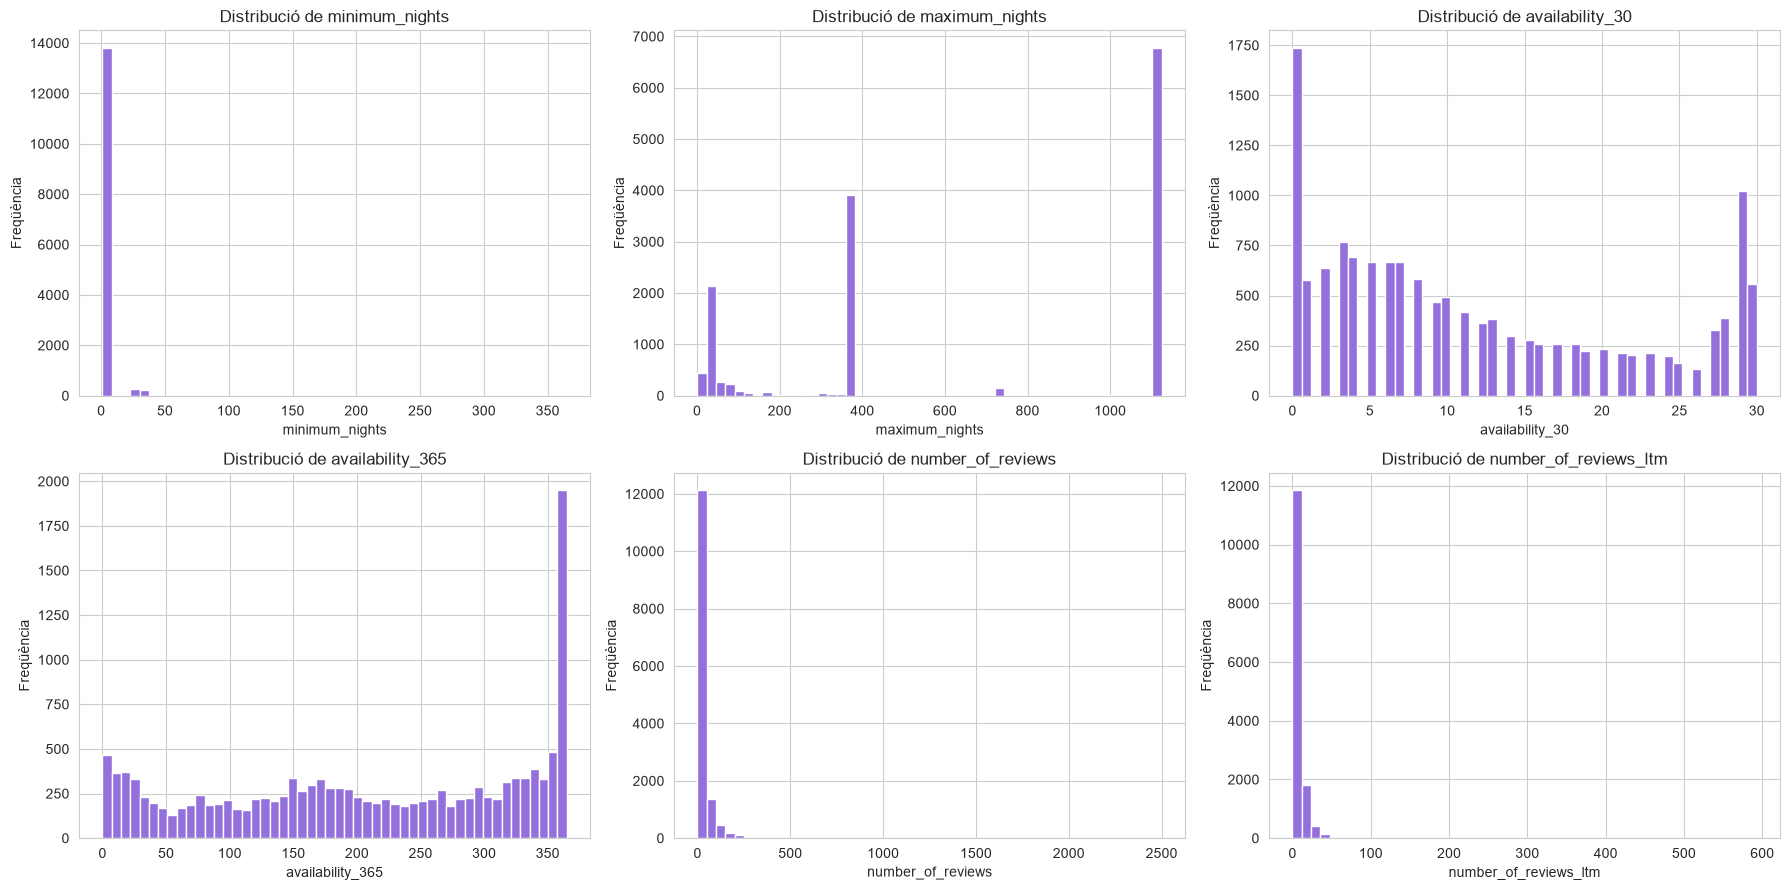

In [29]:
# Altres variables numèriques: disponibilitat, ressenyes, estada mínima
other_vars = [c for c in ['minimum_nights', 'maximum_nights', 'availability_30',
                          'availability_365', 'number_of_reviews', 'number_of_reviews_ltm']
              if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, other_vars):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='mediumpurple', edgecolor='white')
    ax.set_title(f'Distribució de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Freqüència')

plt.tight_layout()
save_fig(fig, 'eda_03_other_numeric_distributions.pdf')
plt.show()

### Observacions sobre les variables numèriques

#### Visió general de les estadístiques

1. **Variables de resposta del host** (`host_response_rate`, `host_acceptance_rate`):
   - Mitjanes molt altes (0,97 i 0,93), **asimetria fortament negativa** (-6,14 i -3,65).
   - La gran majoria de hosts responen i accepten el 100 % de les sol·licituds. Només una petita cua d'hosts amb valors propers a 0 explica l'asimetria.
   - Són variables poc discriminatives (baixa variància efectiva) tot i que tenen rang 0-1. Caldrà valorar si aporten informació útil al model o només soroll.

2. **`host_listings_count`**: mitjana 201,76, mediana 35, màxim 1.564. Asimetria 2,13. Hi ha una presència important de **gestors professionals** (multi-propietat) al costat d'hosts individuals.

3. **Variables de capacitat** (`accommodates`, `bathrooms`, `bedrooms`, `beds`):

    | Variable | Mitjana | Mediana | Màx | Asimetria |
    |---|---|---|---|---|
    | `accommodates` | 5,82 | 6 | 16 | 0,71 |
    | `bathrooms` | 2,35 | 2 | 19 | 1,85 |
    | `bedrooms` | 2,97 | 3 | 20 | 1,07 |
    | `beds` | 4,37 | 4 | 32 | 1,47 |

    La distribució és raonablement **centrada en allotjaments de mida mitjana** (4-6 persones, 2-3 habitacions). Els valors extrems (20 habitacions, 32 llits) són coherents amb grans possessions, no semblen errors.

3. **Variables de disponibilitat**:
   - `minimum_nights`: mediana 1, però **asimetria extrema (15,37)** i màxim 365 dies. La majoria permeten 1 nit, però hi ha una cua amb estades mínimes molt llargues que probablement són lloguers de temporada completa. 
       - **Candidata a transformació logarítmica o binària** (per exemple `min_nights > 7`).
   - `maximum_nights`: mediana 365, màxim 1.125. Molt més estable.
   - `availability_30`: mitjana 11,8, mediana 9. Distribució raonable.
   - `availability_365`: mitjana 208, mediana 212. Bimodal probable, sembla que hi ha allotjaments molt disponibles i de pocs disponibles).

4. **Variables de ressenyes**:

    | Variable | Mediana | Màx | Asimetria |
    |---|---|---|---|
    | `number_of_reviews` | 9 | 2.501 | 12,30 |
    | `number_of_reviews_ltm` | 3 | 593 | 15,80 |
    | `estimated_occupancy_l365d` | 20 | 255 | 1,69 |
    | `estimated_revenue_l365d` | 6.174 | 1.740.000 | 7,18 |

    Totes aquestes variables tenen **cues molt llargues** amb asimetries $>7$. `estimated_revenue_l365d` és especialment extrema (asimetria 7,18) i està directament lligada al preu. Caldrà tenir molta cura de **no fer servir aquesta variable com a *feature*** perquè pot introduirbiaix en la predicció de `price`.

5. **Variables de review scores** (`review_scores_rating`, `_accuracy`, `_cleanliness`, `_checkin`, `_communication`, `_location`, `_value`):
   - Totes amb mitjanes entre 4,56 i 4,81 i **asimetries fortament negatives** (-3,37 a -5,60).
   - Rang limitat a [1, 5], però la distribució està **comprimida al voltant del 4,8**.
   - Això és esperable: les ressenyes d'Airbnb són notòriament esbiaixades cap amunt (només els clients molt satisfets o molt insatisfets escriuen).
   - El `review_scores_value` és el més baix (mitjana 4,56) i potencialment el més relacionat amb el preu subjectiu percebut.

6. **Variables geogràfiques**:
   - `latitude`: rang [39,30; 39,93], mitjana 39,66.
   - `longitude`: rang [2,35; 3,47], mitjana 3,02.
   - `dist_sea_km`: mitjana 4,41, mediana 1,57, màxim 23,65, asimetria 1,35. La majoria d'allotjaments estan **molt a prop de la costa** (mediana <2 km).
   - `dist_palma_center_km`: mitjana 39,83, mediana 46,33, **asimetria negativa (-0,66)**. Això és interessant: la mitjana és **més baixa** que la mediana perquè hi ha una acumulació d'allotjaments a Palma.
   - `dist_airport_km`: patró similar (asimetria -0,51).

#### Comparació de transformacions de `dist_sea_km`

| Variable | Asimetria |
|---|---|
| `dist_sea_km` | 1,35 |
| `dist_sea_squared_km` | 2,44 |
| `dist_sea_log_km` | **-0,25** |

La versió logarítmica és clarament la **més simètrica de les tres**. Això dona suport a prioritzar `log` a la fase de modelització, depenent del model emprat:
- Models lineals: `dist_sea_log_km` (relació més lineal amb `log(price)`).
- Models basats en arbres: `dist_sea_km` directe, ja que els arbres no necessiten linealitat.

#### Índexs agregats

- **`amenity_index`**: mitjana 8,26, mediana 9, asimetria -1,56. La majoria d'allotjaments tenen gairebé totes les amenities de la llista. Aquest índex és poc discriminatiu per si sol (molts valors a 9-10) i pot ser que no aporti gaire al model.
- **`num_listings_neighborhood`**: rang 10-2.299. Trobam municipis molt densos i municipis molt poc densos.
- **`avg_price_neighborhood`**: rang 240,85-3.219,17.

#### Alerta: *leakage* de dades

**S'ha detectat un problema potencial de leakage de dades a tres variables**:

| Variable | Problema |
|---|---|
| `avg_price_neighborhood` | Es calcula a partir de `price` de tots els allotjaments del municipi, incloent-hi el propi. |
| `price_ratio_vs_neighborhood` | És `price / avg_price_neighborhood`. **Conté directament la variable objectiu al numerador**. |
| `estimated_revenue_l365d` | Derivada directament del preu × ocupació estimada. |

La prova més clara és l'estadística de `price_ratio_vs_neighborhood`:

- **Mitjana = 1,00** (per construcció matemàtica: el ratio mitjà ponderat dins de cada barri és 1).
- **Mediana = 0,19** (la majoria d'allotjaments estan per sota de la mitjana del barri).
- **Asimetria = 3,07**.

Si aquesta variable s'inclou com a feature per predir `price`, el model **tindrà accés directe a la resposta** i produirà mètriques artificialment bones que no es reproduiran en producció. **Cal eliminar-la de qualsevol conjunt de features**, igual que `avg_price_neighborhood` (que és la base per calcular-la).

#### Implicacions per a la modelització

1. **Variables a eliminar del conjunt de features per *leakage***:
   - `price_ratio_vs_neighborhood`
   - `avg_price_neighborhood`
   - `estimated_revenue_l365d`
   - (valorar també `estimated_occupancy_l365d`, que no depèn directament del preu però sí del rendiment del mateix anunci)

2. **Variables a eliminar per manca de valor predictiu**:
   - `id`, `host_id`

3. **Transformacions recomanades**:
   - `minimum_nights`: log o binària (`min_nights > 7`)
   - `number_of_reviews` i `number_of_reviews_ltm`: log
   - `dist_sea_km`: ja es té la versió log, prioritzar-la per a models lineals
   - `host_listings_count`: log (asimetria 2,13)

4. **Variables poc discriminatives** que caldrà valorar:
   - `host_response_rate`, `host_acceptance_rate` (concentrades a 1)
   - `amenity_index` (concentrat a 9-10)
   - Review scores individuals (molt correlacionats entre si, possiblement caldrà un PCA o una mitjana)

## 5. Variables binàries i categòriques transformades

Analitzem la freqüència de les variables booleanes generades durant la transformació de categories (room type, property type, amenities, host verifications, etc.).

In [30]:
# Freqüència de les variables booleanes
bool_summary = pd.DataFrame({
    'n_true': df[bool_cols].sum(),
    'pct_true': df[bool_cols].mean() * 100
}).sort_values('pct_true', ascending=False)

print(f"Variables booleanes: {len(bool_cols)}")
print(bool_summary.round(2).to_string())

Variables booleanes: 31
                               n_true  pct_true
has_availability                14342    100.00
verif_phone                     14339     99.98
host_has_profile_pic            14122     98.47
amenity_wifi                    13614     94.92
amenity_kitchen                 13594     94.78
verif_email                     13555     94.51
room_Entire home/apt            13452     93.79
host_identity_verified          13117     91.46
has_license                     12257     85.46
amenity_hair_dryer              12170     84.86
amenity_bed_linens              12043     83.97
amenity_dishes_and_silverware   11760     82.00
has_reviews                     11690     81.51
amenity_microwave               11505     80.22
amenity_iron                    11436     79.74
amenity_refrigerator            11301     78.80
amenity_essentials              10970     76.49
amenity_washer                  10117     70.54
instant_bookable                 9493     66.19
prop_house      

   Figura guardada: eda_04_boolean_frequencies.pdf


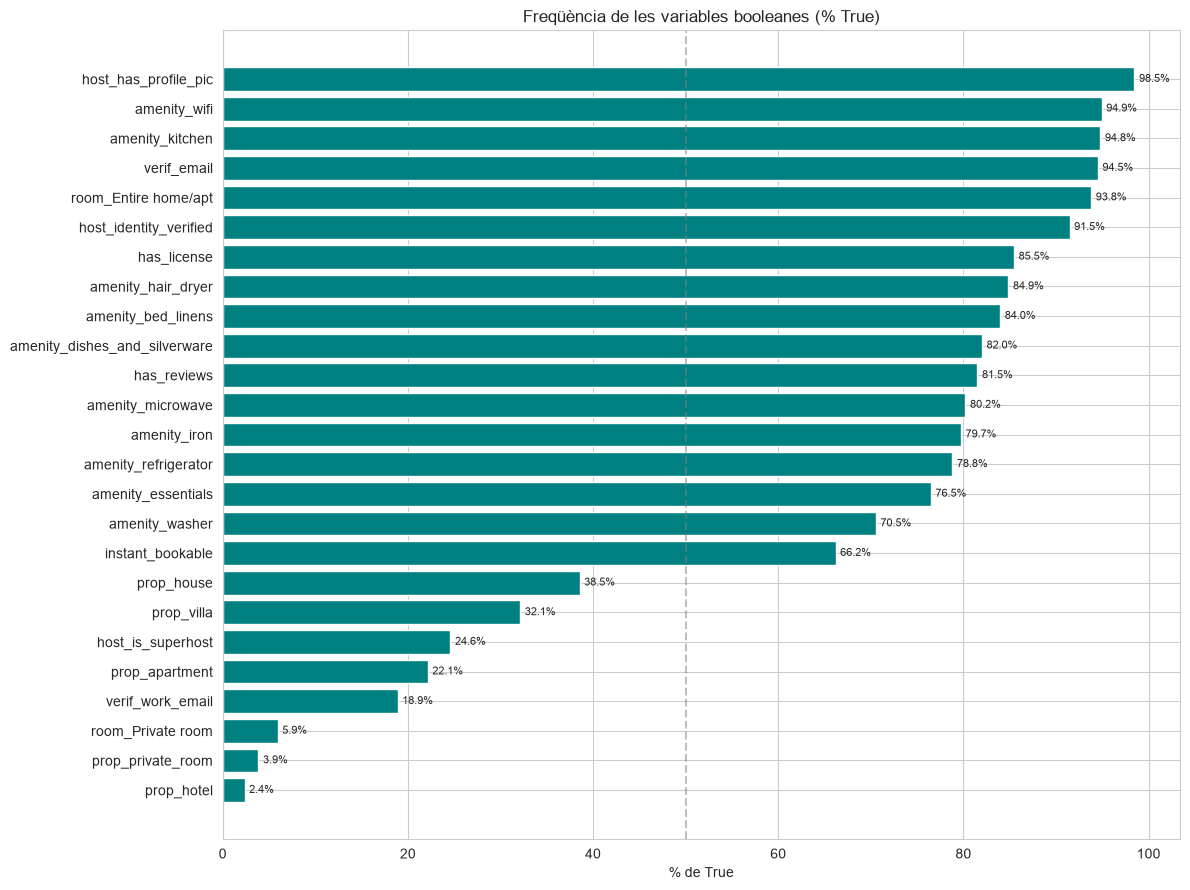

In [31]:
# Visualització de les variables booleanes principals
plot_bool = bool_summary[bool_summary['pct_true'].between(0.5, 99.5)].copy()
plot_bool = plot_bool.sort_values('pct_true', ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(plot_bool.index, plot_bool['pct_true'], color='teal', edgecolor='white')
ax.set_xlabel('% de True')
ax.set_title('Freqüència de les variables booleanes (% True)')
ax.axvline(50, color='gray', linestyle='--', alpha=0.5)
for i, (idx, row) in enumerate(plot_bool.iterrows()):
    ax.text(row['pct_true'] + 0.5, i, f"{row['pct_true']:.1f}%", va='center', fontsize=8)
plt.tight_layout()
save_fig(fig, 'eda_04_boolean_frequencies.pdf')
plt.show()

In [32]:
# Preu per room_type i property_group
room_cols = [c for c in df.columns if c.startswith('room_')]
prop_cols = [c for c in df.columns if c.startswith('prop_')]

def price_by_dummies(df, dummy_cols, prefix):
    rows = []
    for col in dummy_cols:
        subset = df[df[col] == True]
        if len(subset) > 0:
            rows.append({
                'group': col.replace(f'{prefix}_', ''),
                'n': len(subset),
                'pct': len(subset) / len(df) * 100,
                'price_mean': subset['price'].mean(),
                'price_median': subset['price'].median(),
            })
    result = pd.DataFrame(rows).sort_values('price_median', ascending=False)
    print(f"\nPreu per {prefix}:")
    print(result.round(2).to_string(index=False))
    return result

room_stats = price_by_dummies(df, room_cols, 'room')
prop_stats = price_by_dummies(df, prop_cols, 'prop')


Preu per room:
          group     n   pct  price_mean  price_median
Entire home/apt 13452 93.79     1614.51         286.0
     Hotel room    37  0.26      432.70         211.0
    Shared room     2  0.01      170.50         170.5
   Private room   851  5.93      712.61         116.0

Preu per prop:
       group    n   pct  price_mean  price_median
       villa 4608 32.13     1920.64         400.0
       house 5528 38.54     1551.78         296.0
       hotel  338  2.36      662.76         188.5
   apartment 3175 22.14     1326.15         177.0
 shared_room    2  0.01      170.50         170.5
       other  138  0.96      573.60         119.5
private_room  553  3.86      720.66          88.0


   Figura guardada: eda_05_price_by_category.pdf


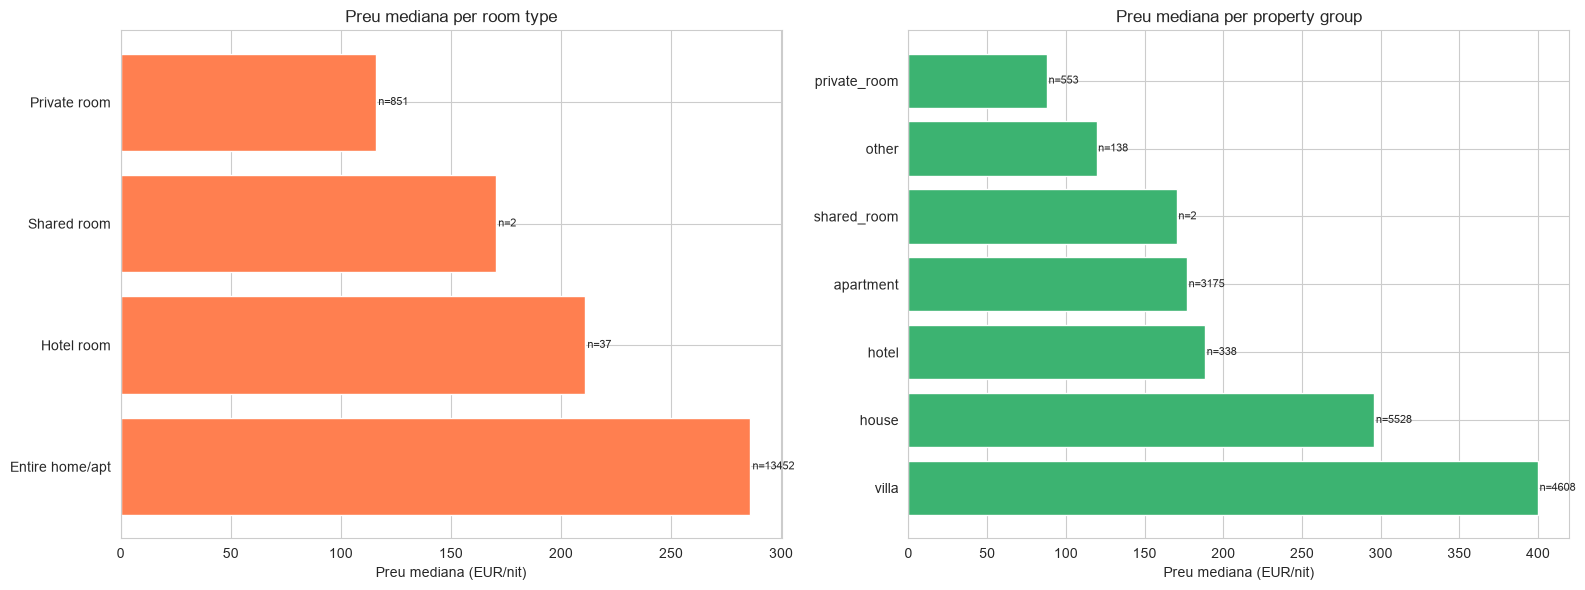

In [33]:
# Visualització del preu per room_type i property_group
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(room_stats['group'], room_stats['price_median'], color='coral', edgecolor='white')
axes[0].set_xlabel('Preu mediana (EUR/nit)')
axes[0].set_title('Preu mediana per room type')
for i, (_, row) in enumerate(room_stats.iterrows()):
    axes[0].text(row['price_median'] + 1, i, f"n={row['n']}", va='center', fontsize=8)

axes[1].barh(prop_stats['group'], prop_stats['price_median'], color='mediumseagreen', edgecolor='white')
axes[1].set_xlabel('Preu mediana (EUR/nit)')
axes[1].set_title('Preu mediana per property group')
for i, (_, row) in enumerate(prop_stats.iterrows()):
    axes[1].text(row['price_median'] + 1, i, f"n={row['n']}", va='center', fontsize=8)

plt.tight_layout()
save_fig(fig, 'eda_05_price_by_category.pdf')
plt.show()

### Observacions sobre les variables categòriques

El dataset conté **31 variables booleanes** generades durant la transformació de categories. Aquestes variables es poden agrupar en cinc blocs:

| Bloc | Variables | Nombre |
|---|---|---|
| Verificacions de l'host | `verif_email`, `verif_phone`, `verif_work_email` | 3 |
| Tipus d'habitació (`room_type`) | `room_Entire home/apt`, `room_Private room`, `room_Shared room`, `room_Hotel room` | 4 |
| Tipus de propietat (`property_type`) | `prop_villa`, `prop_house`, `prop_apartment`, `prop_private_room`, `prop_shared_room`, `prop_hotel`, `prop_other` | 7 |
| Serveis (amenities top 10) | `amenity_wifi`, `amenity_kitchen`, `amenity_hair_dryer`, ... | 10 |
| Altres flags | `host_has_profile_pic`, `host_identity_verified`, `host_is_superhost`, `has_availability`, `instant_bookable`, `has_license`, `has_reviews` | 7 |

#### Variables amb poca o gens variància

Un primer problema detectat és la presència de variables **quasi constants**, que no aportaran cap capacitat predictiva al model:

| Variable | % True | Comentari |
|---|---|---|
| `has_availability` | **100,00 %** | Variància zero → **eliminar** |
| `verif_phone` | 99,98 % | 3 casos amb False → pràcticament constant |
| `host_has_profile_pic` | 98,47 % | Molt concentrada al True |
| `amenity_wifi` | 94,92 % | Pràcticament tots els allotjaments tenen wifi |
| `amenity_kitchen` | 94,78 % | Idem |
| `verif_email` | 94,51 % | Idem |
| `room_Entire home/apt` | 93,79 % | Idem |
| `host_identity_verified` | 91,46 % | Idem |

**Implicacions**:
- `has_availability` s'ha d'eliminar directament (variància = 0).
- `verif_phone` és candidata a eliminar també.
- Les altres caldrà valorar-les amb la matriu de correlacions de la secció 8, ja que tenen algun senyal però molt concentrat al True.

#### Variables amb classe minoritària massa petita

Dues variables tenen un nombre de casos positiu molt petit:

| Variable | n_true | % |
|---|---|---|
| `room_Shared room` | **2** | 0,01 % |
| `prop_shared_room` | **2** | 0,01 % |
| `room_Hotel room` | 37 | 0,26 % |
| `prop_other` | 138 | 0,96 % |

Amb només 2 observacions, `room_Shared room` i `prop_shared_room` **no són útils per a la modelització**: qualsevol model amb aquesta variable sofrirà un sobreajustament extrem o bé l'ignorarà per complet. Es recomana:
- **Eliminar-les** del conjunt de features.
- O bé **fusionar-les** amb una categoria "altres" més àmplia.

`prop_hotel` (2,36 %) i `room_Hotel room` (0,26 %) són també molt minoritàries i caldrà vigilar el seu impacte.

#### Distribució del mercat per tipologia

**Tipus d'habitació** (percentatge sobre el total):

| Categoria | n | % |
|---|---|---|
| `room_Entire home/apt` | 13.452 | 93,79 % |
| `room_Private room` | 851 | 5,93 % |
| `room_Hotel room` | 37 | 0,26 % |
| `room_Shared room` | 2 | 0,01 % |

**Tipus de propietat**:

| Categoria | n | % |
|---|---|---|
| `prop_house` | 5.528 | 38,54 % |
| `prop_villa` | 4.608 | 32,13 % |
| `prop_apartment` | 3.175 | 22,14 % |
| `prop_private_room` | 553 | 3,86 % |
| `prop_hotel` | 338 | 2,36 % |
| `prop_other` | 138 | 0,96 % |
| `prop_shared_room` | 2 | 0,01 % |

El mercat està dominat clarament per **cases i finques** (70,67 % del total), seguit d'apartaments (22,14 %). La resta són fraccions menors.

#### Preu per tipologia d'allotjament

**Preu mediana per `room_type`** (EUR/vespre):

| Categoria | n | Mediana | Mitjana |
|---|---|---|---|
| `Entire home/apt` | 13.452 | **286,0 €** | 1.614,51 € |
| `Hotel room` | 37 | 211,0 € | 432,70 € |
| `Shared room` | 2 | 170,5 € | 170,50 € |
| `Private room` | 851 | **116,0 €** | 712,61 € |

**Preu mediana per `property_group`** (EUR/vespre):

| Categoria | n | Mediana | Mitjana |
|---|---|---|---|
| `villa` | 4.608 | **400,0 €** | 1.920,64 € |
| `house` | 5.528 | **296,0 €** | 1.551,78 € |
| `hotel` | 338 | 188,5 € | 662,76 € |
| `apartment` | 3.175 | **177,0 €** | 1.326,15 € |
| `shared_room` | 2 | 170,5 € | 170,50 € |
| `other` | 138 | 119,5 € | 573,60 € |
| `private_room` | 553 | **88,0 €** | 720,66 € |

1. **Jerarquia de preus**: la mediana del preu segueix un gradient molt nítid `villa > house > hotel ≈ apartment > private_room`. La diferència entre la categoria més cara (`villa`, 400 €) i la més barata (`private_room`, 88 €) és d'un **factor de 4,5×**.

2. **Villa vs apartment**: tot i que els apartaments (n=3.175) són una categoria rellevant, la seva mediana (177 €) és menys de la meitat que la de les vil·les (400 €). Aquesta diferència és coherent amb el mercat balear i **serà un predictor fort**.

3. **Discrepància entre mediana i mitjana**: a totes les categories la mitjana és entre 3 i 7 vegades més gran que la mediana. Això és **coherent amb el patró que ja vam veure a `price`** i reforça la necessitat d'entrenar sobre `log(price)` o d'eliminar els valors extrems.

4. **`other` i `private_room`** tenen medianes molt baixes i mides de mostra reduïdes. Caldrà veure si aporten només soroll.

#### Implicacions per a la modelització

1. **Eliminar**:
   - `has_availability` (variància zero).
   - `room_Shared room` i `prop_shared_room` (només 2 casos).
   - Valorar eliminar `verif_phone` (3 casos a False).

2. **Fusionar o vigilar**:
   - `room_Hotel room` (37 casos) i `prop_other` (138 casos): masses mostres petites per a un dummy independent.
   - Possible creació d'una variable `room_other` que agrupi `Shared room` + `Hotel room`.

3. **Confiar com a *features* a incloure al model**:
   - `prop_villa`, `prop_house`, `prop_apartment`: mostren diferències de preu clares i tenen mides de mostra suficients.
   - `room_Entire home/apt` vs `room_Private room`: molt predictives (encara que desbalancejades).

4. **Considerar reducció de dimensionalitat** per a les 10 amenities: com que gairebé totes les variables tenen >70 % True i estan fortament correlacionades entre si, potser és més eficient quedar-se amb `amenity_index` (índex agregat) que amb les 10 columnes individuals.

## 6. Anàlisi geogràfica

Mallorca és una illa amb una geografia molt marcada (costa vs interior, Palma vs resta). Analitzem com es distribueixen els allotjaments i com es relaciona la ubicació amb el preu.

   Figura guardada: eda_06_geographic_price_map.pdf


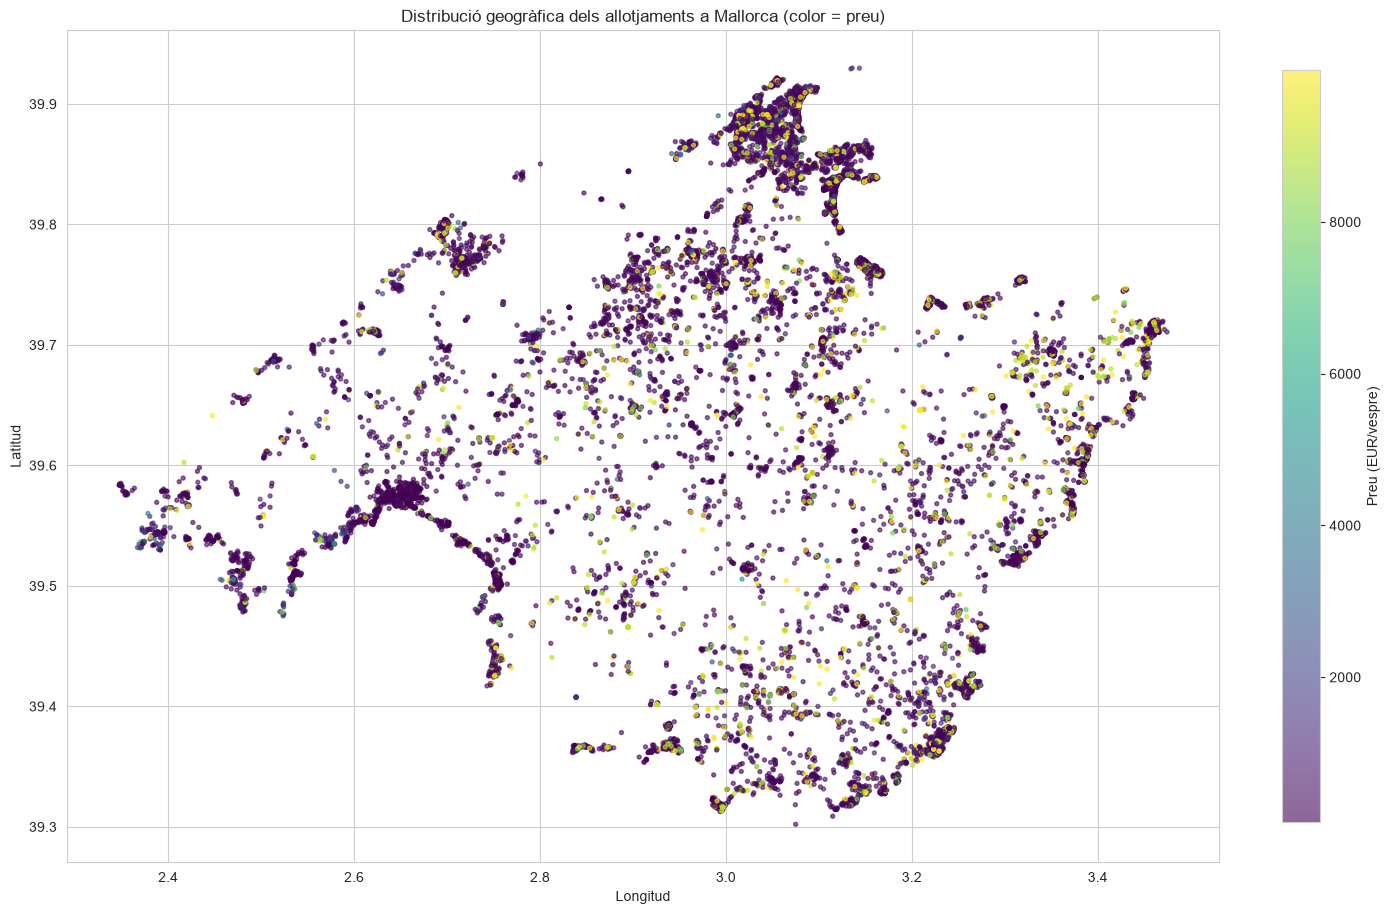

In [40]:
# Mapa de dispersió geogràfica, acolorit pel preu
fig, ax = plt.subplots(figsize=(14, 10))

vmin = df['price'].quantile(0.05)
vmax = df['price'].quantile(0.95)

sc = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['price'], cmap='viridis',
    s=8, alpha=0.6,
    vmin=vmin, vmax=vmax
)
cbar = plt.colorbar(sc, ax=ax, fraction=0.03)
cbar.set_label('Preu (EUR/vespre)')

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Distribució geogràfica dels allotjaments a Mallorca (color = preu)')
ax.set_aspect(1 / np.cos(np.radians(39.5)))
plt.tight_layout()
save_fig(fig, 'eda_06_geographic_price_map.pdf')
plt.show()

   Figura guardada: eda_07_price_vs_distance_sea.pdf


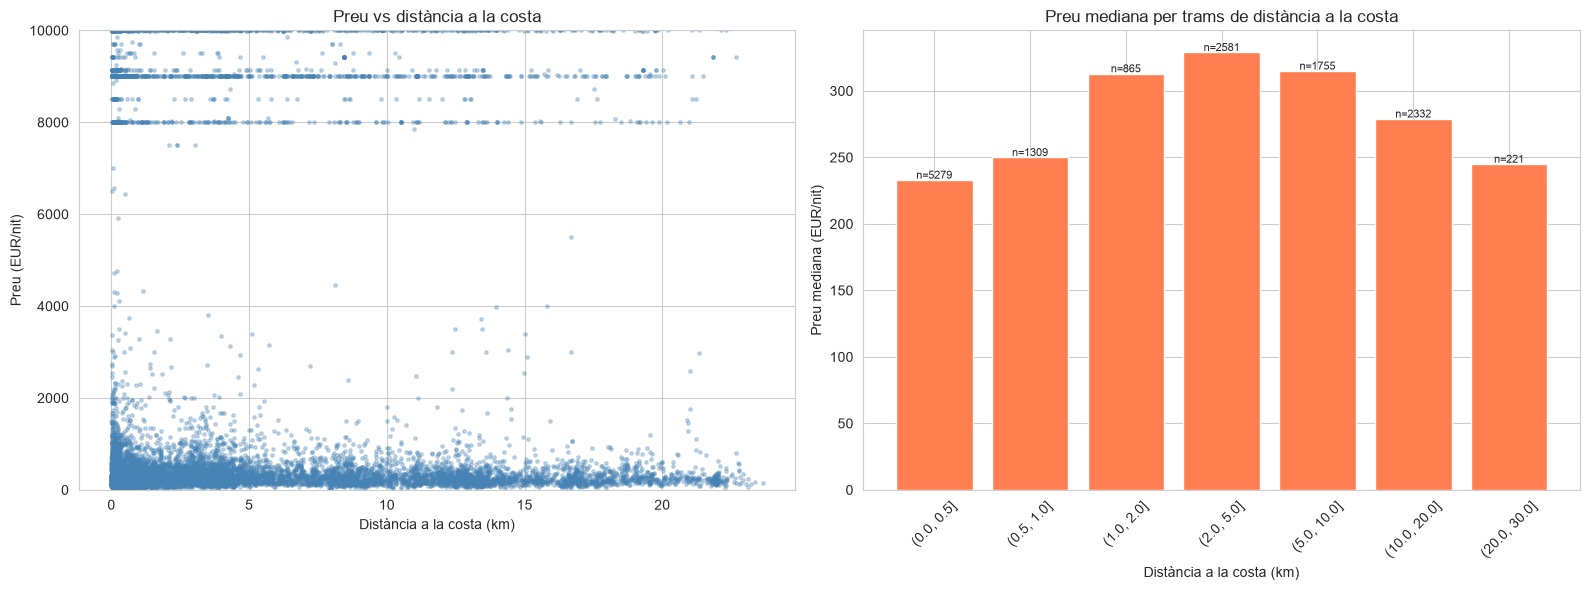


Preu per tram de distància a la costa:
_dist_sea_bin  median    mean  count
   (0.0, 0.5]   233.0 1437.21   5279
   (0.5, 1.0]   250.0 1321.10   1309
   (1.0, 2.0]   313.0 1426.67    865
   (2.0, 5.0]   329.0 1629.43   2581
  (5.0, 10.0]   315.0 1970.18   1755
 (10.0, 20.0]   279.0 1672.01   2332
 (20.0, 30.0]   245.0 1033.19    221


In [ ]:
# Relació entre distància a la costa i preu
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['dist_sea_km'], df['price'], s=6, alpha=0.3, color='steelblue')
axes[0].set_xlabel('Distància a la costa (km)')
axes[0].set_ylabel('Preu (EUR/vespre)')
axes[0].set_title('Preu vs distància a la costa')
axes[0].set_ylim(0, df['price'].quantile(0.99))

# Anàlisi per trams per veure la tendència sense outliers
bins = [0, 0.5, 1, 2, 5, 10, 20, 30]
df['_dist_sea_bin'] = pd.cut(df['dist_sea_km'], bins=bins)
binned = df.groupby('_dist_sea_bin')['price'].agg(['median', 'mean', 'count']).reset_index()
binned['_dist_sea_bin'] = binned['_dist_sea_bin'].astype(str)

axes[1].bar(binned['_dist_sea_bin'], binned['median'], color='coral', edgecolor='white')
axes[1].set_xlabel('Distància a la costa (km)')
axes[1].set_ylabel('Preu mediana (EUR/nit)')
axes[1].set_title('Preu mediana per trams de distància a la costa')
for i, (_, row) in enumerate(binned.iterrows()):
    axes[1].text(i, row['median'] + 1, f"n={int(row['count'])}", ha='center', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig(fig, 'eda_07_price_vs_distance_sea.pdf')
plt.show()

print("\nPreu per tram de distància a la costa:")
print(binned.round(2).to_string(index=False))

   Figura guardada: eda_08_price_vs_distance_poi.pdf


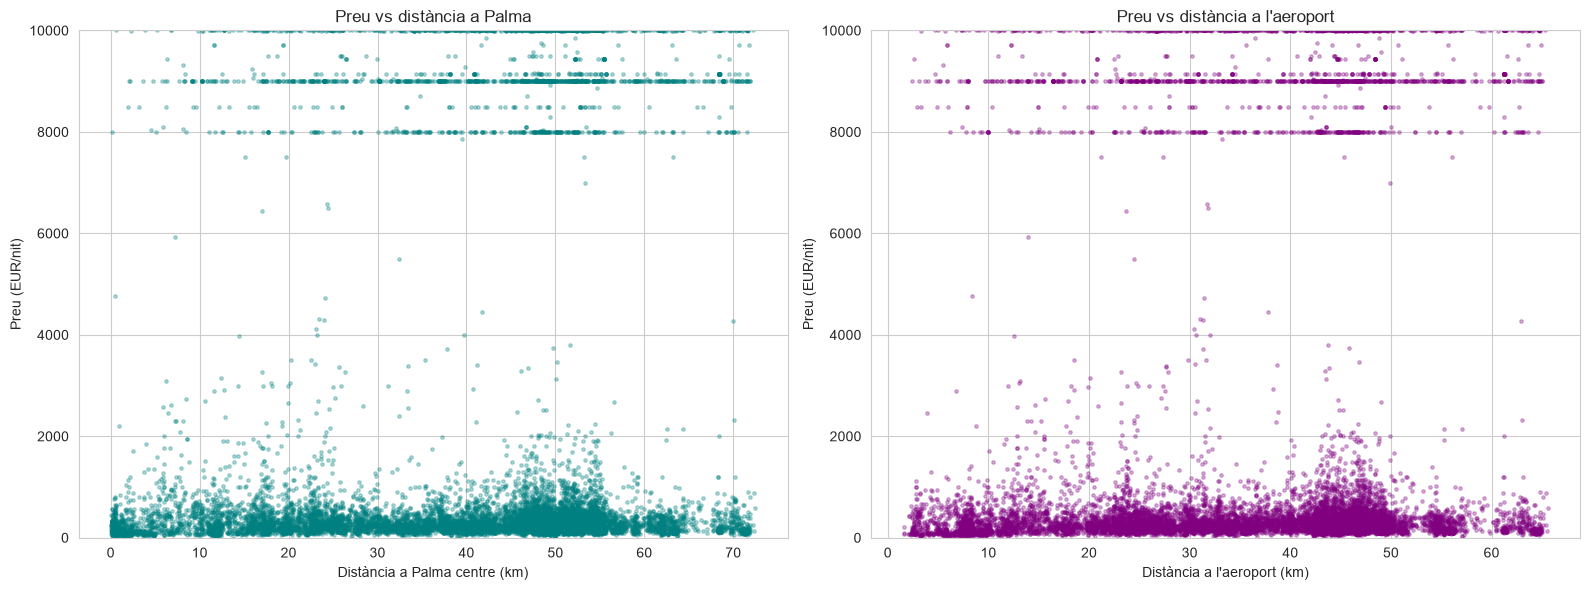

In [36]:
# Distància a Palma i a l'aeroport
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['dist_palma_center_km'], df['price'], s=6, alpha=0.3, color='teal')
axes[0].set_xlabel('Distància a Palma centre (km)')
axes[0].set_ylabel('Preu (EUR/nit)')
axes[0].set_title('Preu vs distància a Palma')
axes[0].set_ylim(0, df['price'].quantile(0.99))

axes[1].scatter(df['dist_airport_km'], df['price'], s=6, alpha=0.3, color='purple')
axes[1].set_xlabel("Distància a l'aeroport (km)")
axes[1].set_ylabel('Preu (EUR/nit)')
axes[1].set_title("Preu vs distància a l'aeroport")
axes[1].set_ylim(0, df['price'].quantile(0.99))

plt.tight_layout()
save_fig(fig, 'eda_08_price_vs_distance_poi.pdf')
plt.show()

### Observacions sobre l'anàlisi geogràfica

#### Distribució dels allotjaments

El mapa de dispersió amb `longitude` a l'eix X i `latitude` a l'eix Y reprodueix la silueta de Mallorca i permet identificar visualment diversos patrons:

1. **Concentració costanera**: la major part dels allotjaments es distribueixen en una corona al voltant de l'illa, seguint la línia de costa. Aquest patró és especialment visible al nord (zona de Pollença-Alcúdia), a l'est (zona de Manacor-Cala Millor) i al sud-oest (zona de Palma i Andratx).
2. **Palma com a focus principal**: la zona de Palma (aproximadament a `longitude ≈ 2,65` i `latitude ≈ 39,57`) apareix com un nucli molt dens, coherent amb el fet que concentra la major part de població i oferta turística urbana.
3. **Gradient de preu poc intuïtiu**: al mapa, els punts grocs (preus alts) no estan concentrats només a primera línia de mar. N'hi ha molts a l'interior i a la Serra de Tramuntana (nord-oest), cosa que apunta que **el preu no està directament determinat per la proximitat a la costa**.

#### Preu vs distància a la costa

El gràfic de dispersió directe no és especialment informatiu perquè està dominat pel pic de 10.000 € (que apareix com a línies horitzontals visibles a 8.000, 9.000 i 10.000 €). En canvi, quan s'agrupa per trams, apareix un patró **contraintuïtiu i molt rellevant**:

| Tram (km) | n | Mediana (€) | Mitjana (€) |
|---|---|---|---|
| (0, 0,5] | 5.279 | **233** | 1.437 |
| (0,5, 1] | 1.309 | 250 | 1.321 |
| (1, 2] | 865 | 313 | 1.427 |
| (2, 5] | 2.581 | **329** | 1.629 |
| (5, 10] | 1.755 | **315** | 1.970 |
| (10, 20] | 2.332 | 279 | 1.672 |
| (20, 30] | 221 | 245 | 1.033 |

La relació entre distància a la costa i preu **no és lineal ni monòtona**. La mediana del preu **puja** des de la primera línia de mar (233 €) fins a un màxim al tram **2-10 km** (315-329 €), i després **baixa** a partir dels 10 km. Això contradiu la intuïció que "com més a prop del mar, més car".

**Implicacions**:
- La variable `dist_sea_km` **no es pot modelitzar com a relació lineal simple**. Caldrà:
  - Fer servir la versió logarítmica (`dist_sea_log_km`) per a models lineals.
  - O bé incloure una **transformació no lineal** (per exemple, `dist_sea_km` i `dist_sea_squared_km` conjuntament) per capturar la forma de U invertida.
  - O bé deixar que els models basats en arbres (`Random Forest`, `Gradient Boosting`) la capturin automàticament.

#### Preu vs distància a Palma

El patró és encara menys clar. S'observa que:

1. **Hi ha molt pocs allotjaments a menys de 5 km de Palma centre**. El nucli pur de la ciutat té poca oferta d'Airbnb.
2. La massa principal d'allotjaments es concentra entre **30 i 55 km** de Palma, que correspon a la distància a la qual es troben les zones costaneres del nord, est i sud-est de l'illa.
3. No hi ha un gradient clar de preu en funció de la distància a Palma: preus alts apareixen a qualsevol distància.

**Conclusió**: `dist_palma_center_km` **no sembla un predictor del preu**. Més aviat és una variable que descriu la ubicació geogràfica dins l'illa, i probablement aportarà informació al model només en combinació amb altres variables (com `neighbourhood_cleansed` o `dist_sea_km`).

#### Preu vs distància a l'aeroport

El patró és pràcticament idèntic al de Palma, com era d'esperar atesa la proximitat entre Palma centre i l'aeroport (menys de 10 km en línia recta). La distribució de punts segueix la mateixa forma bimodal:

- Pocs allotjaments a prop de l'aeroport (<5 km).
- Concentració forta entre 30 i 55 km.
- Sense gradient clar de preu.

**Conclusió**: `dist_airport_km` probablement és **redundant** amb `dist_palma_center_km` (caldrà verificar-ho a la matriu de correlacions de la secció 8). Si el resultat confirma la redundància, es pot prescindir d'una de les dues.

#### Confirmació del pic artificial a ~10.000 €

Els gràfics de dispersió confirmen visualment el vist a la secció 3: hi ha **dues línies horitzontals molt marcades** a ~9.000 € i ~10.000 € que apareixen independentment de la distància a la costa, a Palma o a l'aeroport. Això reforça que:

- El pic **no és geogràficament específic**: afecta allotjaments de tota l'illa.
- És un artefacte global del dataset (probablement una fita del preu de la plataforma).
- La decisió de **filtrar o winsoritzar** aquests valors és encara més important, perquè contaminaran qualsevol model geogràfic.

#### Implicacions per a la modelització

1. **`dist_sea_km` és una variable útil però no lineal**. Cal incloure-la juntament amb la seva versió al quadrat (que ja es té) o deixar que els arbres la capturin.

2. **`dist_palma_center_km` i `dist_airport_km`** probablement aporten poc valor predictiu individualment i poden ser redundants entre si. Caldria considerar:
   - Eliminar `dist_airport_km` si la correlació amb `dist_palma_center_km` és >0,9.
   - O bé mantenir-ne només una.

3. **`neighbourhood_cleansed`** es confirma com una variable potencialment molt informativa per capturar efectes locals que les distàncies lineals no recullen.

4. **Confirmació del pic artificial a 10.000 €** com a problema global del dataset, no localitzat. Reforça la necessitat de tractar-lo a la fase de preprocessat.

## 7. Anàlisi de les variables de feature engineering

Analitzem específicament les variables creades durant el feature engineering per veure si aporten informació rellevant.

   Figura guardada: eda_09_amenity_index.pdf


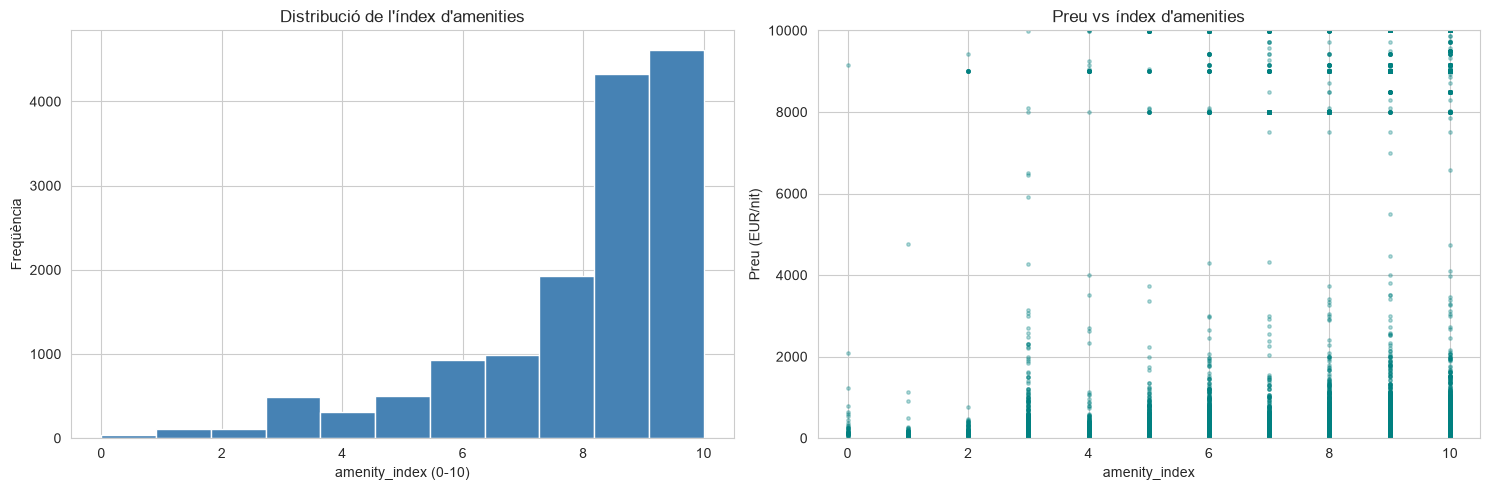


Preu mitjà per amenity_index:
               count     mean  median
amenity_index                        
0                 41   507.93   163.0
1                109   170.65    99.0
2                109   905.29   144.0
3                493   468.87   239.0
4                308  1102.67   190.5
5                499  1220.11   230.0
6                925  1412.77   300.0
7                992  1872.99   265.0
8               1924  1417.64   276.0
9               4329  1189.55   277.0
10              4613  2163.77   295.0


In [37]:
# Distribució de amenity_index
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['amenity_index'], bins=11, color='steelblue', edgecolor='white')
axes[0].set_xlabel('amenity_index (0-10)')
axes[0].set_ylabel('Freqüència')
axes[0].set_title("Distribució de l'índex d'amenities")

axes[1].scatter(df['amenity_index'], df['price'], s=6, alpha=0.3, color='teal')
axes[1].set_xlabel('amenity_index')
axes[1].set_ylabel('Preu (EUR/nit)')
axes[1].set_title("Preu vs índex d'amenities")
axes[1].set_ylim(0, df['price'].quantile(0.99))

plt.tight_layout()
save_fig(fig, 'eda_09_amenity_index.pdf')
plt.show()

print("\nPreu mitjà per amenity_index:")
print(df.groupby('amenity_index')['price'].agg(['count', 'mean', 'median']).round(2))

   Figura guardada: eda_10_neighborhood_features.pdf


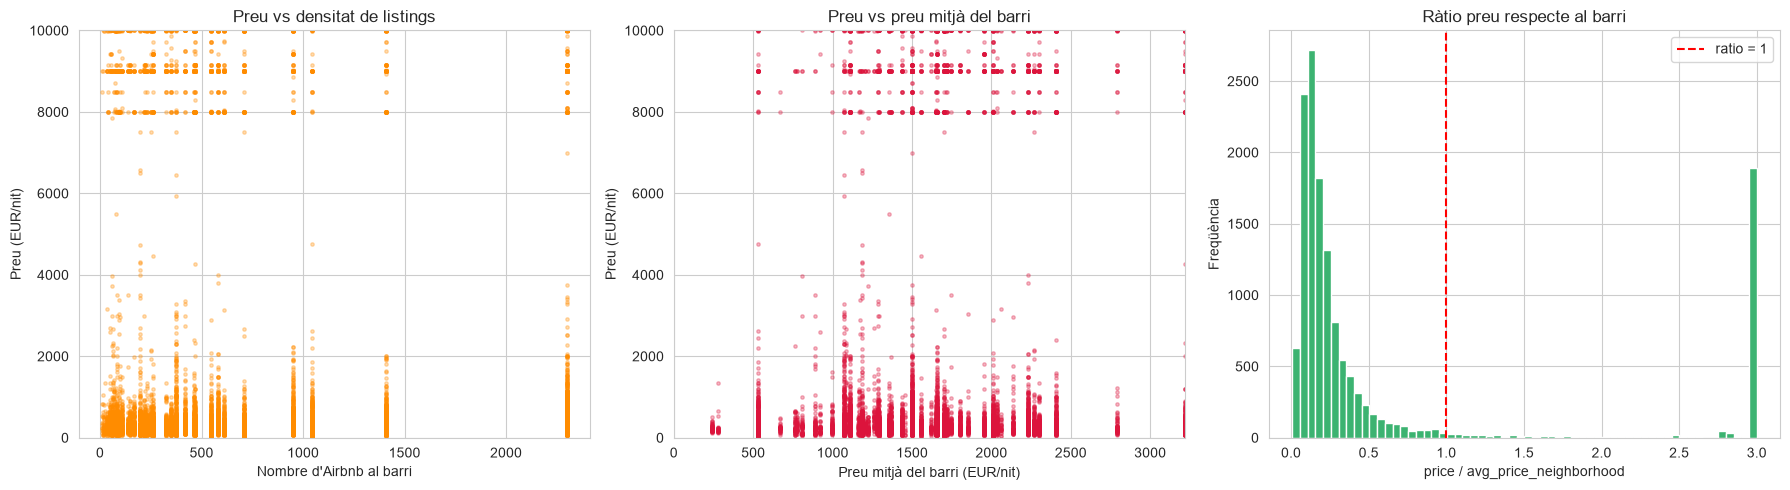

In [38]:
# Variables per municipi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['num_listings_neighborhood'], df['price'], s=6, alpha=0.3, color='darkorange')
axes[0].set_xlabel("Nombre d'Airbnb al barri")
axes[0].set_ylabel('Preu (EUR/nit)')
axes[0].set_title('Preu vs densitat de listings')
axes[0].set_ylim(0, df['price'].quantile(0.99))

axes[1].scatter(df['avg_price_neighborhood'], df['price'], s=6, alpha=0.3, color='crimson')
axes[1].set_xlabel('Preu mitjà del barri (EUR/nit)')
axes[1].set_ylabel('Preu (EUR/nit)')
axes[1].set_title('Preu vs preu mitjà del barri')
axes[1].set_ylim(0, df['price'].quantile(0.99))
axes[1].set_xlim(0, df['avg_price_neighborhood'].quantile(0.99))

axes[2].hist(df['price_ratio_vs_neighborhood'].clip(0, 3), bins=60,
             color='mediumseagreen', edgecolor='white')
axes[2].axvline(1, color='red', linestyle='--', label='ratio = 1')
axes[2].set_xlabel('price / avg_price_neighborhood')
axes[2].set_ylabel('Freqüència')
axes[2].set_title('Ràtio preu respecte al barri')
axes[2].legend()

plt.tight_layout()
save_fig(fig, 'eda_10_neighborhood_features.pdf')
plt.show()

### Observacions sobre feature engineering

#### `amenity_index` 

La distribució de `amenity_index` (rang 0-10) és **asimètrica cap als valors alts**:

| Valor | n | % |
|---|---|---|
| 0-5 | 1.559 | 10,9 % |
| 6-8 | 3.841 | 26,8 % |
| 9 | 4.329 | 30,2 % |
| 10 | 4.613 | 32,2 % |

**Més del 62 % dels allotjaments tenen 9 o 10 amenities** de les 10 més freqüents. Això és coherent amb el fet que les 10 amenities seleccionades (wifi, cuina, assecador, etc.) són serveis **pràcticament universals** en allotjaments turístics de qualitat mínima. La variable, doncs, té poca capacitat discriminativa per si sola.

Tanmateix, la relació amb el preu **no és nul·la**:

| amenity_index | n | Mediana (€) | Mitjana (€) |
|---|---|---|---|
| 0 | 41 | 163,0 | 507,93 |
| 1 | 109 | **99,0** | 170,65 |
| 2 | 109 | 144,0 | 905,29 |
| 3 | 493 | 239,0 | 468,87 |
| 4 | 308 | 190,5 | 1.102,67 |
| 5 | 499 | 230,0 | 1.220,11 |
| 6 | 925 | **300,0** | 1.412,77 |
| 7 | 992 | 265,0 | 1.872,99 |
| 8 | 1.924 | 276,0 | 1.417,64 |
| 9 | 4.329 | 277,0 | 1.189,55 |
| 10 | 4.613 | **295,0** | 2.163,77 |


1. **Tendència ascendent**: del valor 1 (99 €) al valor 10 (295 €), la mediana es triplica. Tot i no ser perfectament monòtona (hi ha alguna oscil·lació als valors 3 i 7), la relació general és positiva.
2. **Els valors 9 i 10 concentren el 62 % de les dades** amb medianes molt semblants (277 € i 295 €). Això significa que la variable **només discrimina bé a la part baixa de l'escala** (0-6 amenities).
3. **Els grups amb amenity_index baix** tenen mides de mostra petites (41, 109, 109) i mitjanes molt inestables (1 amb 170 € però 2 amb 905 €). Això és un senyal que **les mitjanes estan dominades pels valors extrems** i no són representatives.
4. La mediana és molt més estable que la mitjana, com s'esperava.

**Recomanació**: 
- Com a feature única, `amenity_index` aporta informació modesta però no nul·la.
- Atesa la concentració extrema als valors 9-10, pot ser útil **binaritzar-la**: `amenity_index >= 8` (o `>= 9`) com a indicador d'allotjament "completament equipat" i deixar els valors baixos com a categoria separada.
- Alternativament, deixar les 10 variables binàries originals i deixar que el model triï (els arbres gestionen bé la redundància; els models lineals patiran per multicol·linealitat).

#### `num_listings_neighborhood` — Densitat de l'oferta

El gràfic de dispersió mostra una distribució de punts pràcticament **ortogonal al preu**: els preus alts i baixos apareixen a qualsevol nivell de densitat de listings al municipi. No s'observa cap gradient clar.

Alguns municipi tenen només 10 listings; d'altres arriben a 2.299. Aquesta variació tan gran reflecteix **diferències estructurals entre municipis rurals petits i zones turístiques massificades** (Palma, Alcúdia, Cala Millor, etc.). Però el preu no sembla dependre directament d'aquesta densitat.

**Recomanació**: mantenir com a feature potencialment útil per al model (pot interactuar amb altres variables), però no esperar-ne una contribució forta.

#### `avg_price_neighborhood` — Preu mitjà del barri

El gràfic de dispersió mostra que, efectivament, hi ha una relació positiva entre el preu mitjà del barri i el preu individual, però:

1. **El senyal està contaminat pel pic artificial** a 9.000-10.000 €, que apareix com a línies horitzontals de punts. Aquests punts, a més, esbiaixen la mitjana del barri cap amunt.
2. La dispersió al voltant de la tendència és enorme: per a un mateix valor de `avg_price_neighborhood`, el preu individual pot variar entre 50 € i 5.000 €.
3. Tot i la relació aparent, aquesta variable **no es pot fer servir com a feature** perquè conté `price` al càlcul (vegeu 7.4).

#### `price_ratio_vs_neighborhood` — *leakage*

- El **pic principal** està al voltant de **0,15-0,25**, coherent amb el fet que la mediana de `price` (275 €) és molt inferior a la mitjana (1.557 €): com que el ratio es calcula respecte a la mitjana del barri, i la mitjana del barri està inflada pels valors alts, el ratio típic queda per sota de 1.
- Hi ha un **pic artificial a 3,0**, que és exactament el valor de retallada (`clip(0, 3)`) aplicat a la gràfica → confirma que hi ha molts valors per sobre de 3 que s'han tallat per a la visualització.
- La línia vermella a `ratio = 1` marca l'equilibri, i **molt pocs allotjaments hi cauen**.

**Aquesta distribució confirma el problema de *leakage* detectat a la secció 4**:

- `price_ratio_vs_neighborhood` **conté `price` directament al numerador**. Incloure-la com a feature per predir `price` donaria al model accés directe a la resposta.
- La mitjana de la variable és **exactament 1,00** per construcció matemàtica (dins de cada barri, el ratio mitjà ponderat per nombre de listings és 1), cosa que és un senyal inequívoc de dependència amb la target.

**Conclusió**: aquesta variable i la seva base (`avg_price_neighborhood`) **s'han d'eliminar del conjunt de features** a la fase de modelització. Poden servir per a anàlisi descriptiva o com a referència de mercat, però no com a predictors.

#### Implicacions per a la modelització

D'aquesta secció es desprenen les decisions següents:

| Variable | Decisió | Motiu |
|---|---|---|
| `amenity_index` | Mantenir (o binaritzar) | Senyal modest però real; alta concentració a 9-10 |
| `num_listings_neighborhood` | Mantenir | Possible interacció amb altres variables; contribució feble individualment |
| `avg_price_neighborhood` | **Eliminar** | Conté `price` al càlcul: *leakage* |
| `price_ratio_vs_neighborhood` | **Eliminar** | Conté `price` directament: *leakage* |

**Nota metodològica important**: aquesta és la segona vegada que detectem problemes de *leakage* (la primera va ser a la secció 4 amb `estimated_revenue_l365d`). Això és habitual quan es fan servir agregats calculats sobre el propi dataset. **Cal documentar-ho explícitament a la memòria del TFM** i assegurar-se que a la fase de modelització aquestes variables queden fora del conjunt de features.

## 8. Matriu de correlacions

Calculem les correlacions de totes les variables numèriques i booleanes amb `price` per identificar els predictors més forts. També revisem possibles problemes de multicol·linealitat.

In [41]:
# Variables a incloure a la correlació: numèriques + booleanes (com 0/1)
# --- Columnes a excloure de la correlació ---
id_cols = ['id', 'listing_id', 'host_id']                 # <-- ajusta
datetime_cols = ['last_review', 'first_review']           # <-- ajusta
descriptive_cols = ['name', 'description', 'neighbourhood'] # <-- ajusta
bool_cols = df.select_dtypes(include='bool').columns.tolist()

corr_df = df.copy()
corr_df = corr_df.drop(columns=[c for c in id_cols + datetime_cols + descriptive_cols if c in corr_df.columns])
corr_df = corr_df.drop(columns=['_dist_sea_bin'], errors='ignore')

# Convertim booleanes a int per poder correlacionar
for c in bool_cols:
    corr_df[c] = corr_df[c].astype(int)

# Correlació de Pearson amb price
corr_with_price = corr_df.corr(numeric_only=True)['price'].drop('price').sort_values(key=abs, ascending=False)
print("Top 20 correlacions (Pearson) amb price:")
print(corr_with_price.head(20).round(3).to_string())
print()
print(f"Correlacions molt baixes (|r| < 0.05): {(corr_with_price.abs() < 0.05).sum()} variables")

# Correlació de Spearman (més robusta a outliers)
spearman = corr_df.corr(method='spearman', numeric_only=True)['price'].drop('price').sort_values(key=abs, ascending=False)
print("\nTop 10 correlacions (Spearman) amb price:")
print(spearman.head(10).round(3).to_string())

Top 20 correlacions (Pearson) amb price:
price_ratio_vs_neighborhood    0.917
availability_30                0.490
estimated_revenue_l365d        0.449
host_identity_verified        -0.417
availability_365               0.406
host_listings_count            0.306
estimated_occupancy_l365d     -0.234
instant_bookable               0.231
has_reviews                   -0.190
verif_work_email              -0.188
amenity_refrigerator           0.185
avg_price_neighborhood         0.181
amenity_washer                 0.173
host_is_superhost             -0.165
number_of_reviews             -0.155
minimum_nights                -0.152
number_of_reviews_ltm         -0.141
has_license                    0.141
amenity_microwave              0.122
host_acceptance_rate           0.119

Correlacions molt baixes (|r| < 0.05): 24 variables

Top 10 correlacions (Spearman) amb price:
price_ratio_vs_neighborhood    0.895
accommodates                   0.532
bedrooms                       0.521
bathrooms   

   Figura guardada: eda_11_correlations_with_price.pdf


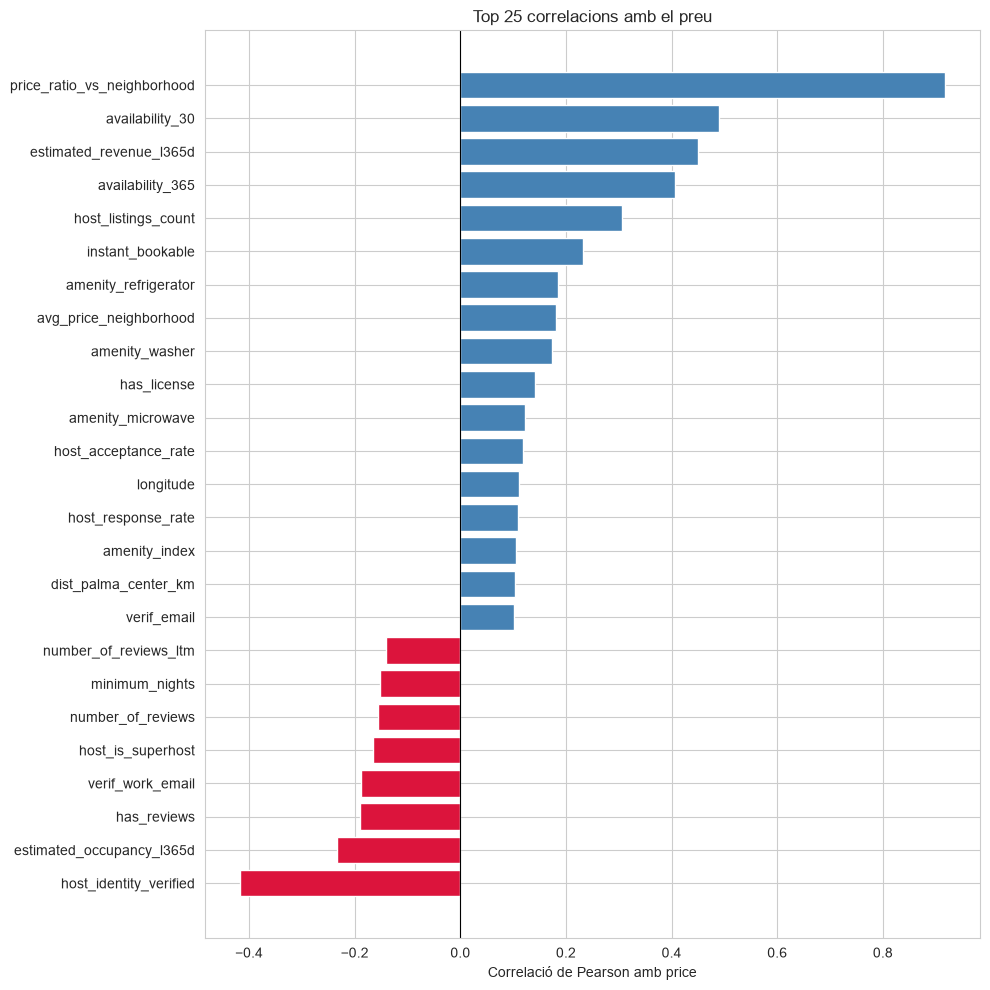

In [42]:
# Bar chart de les top correlacions amb price
top_corr = corr_with_price.head(25).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['crimson' if v < 0 else 'steelblue' for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlació de Pearson amb price')
ax.set_title('Top 25 correlacions amb el preu')
plt.tight_layout()
save_fig(fig, 'eda_11_correlations_with_price.pdf')
plt.show()

   Figura guardada: eda_12_correlation_heatmap.pdf


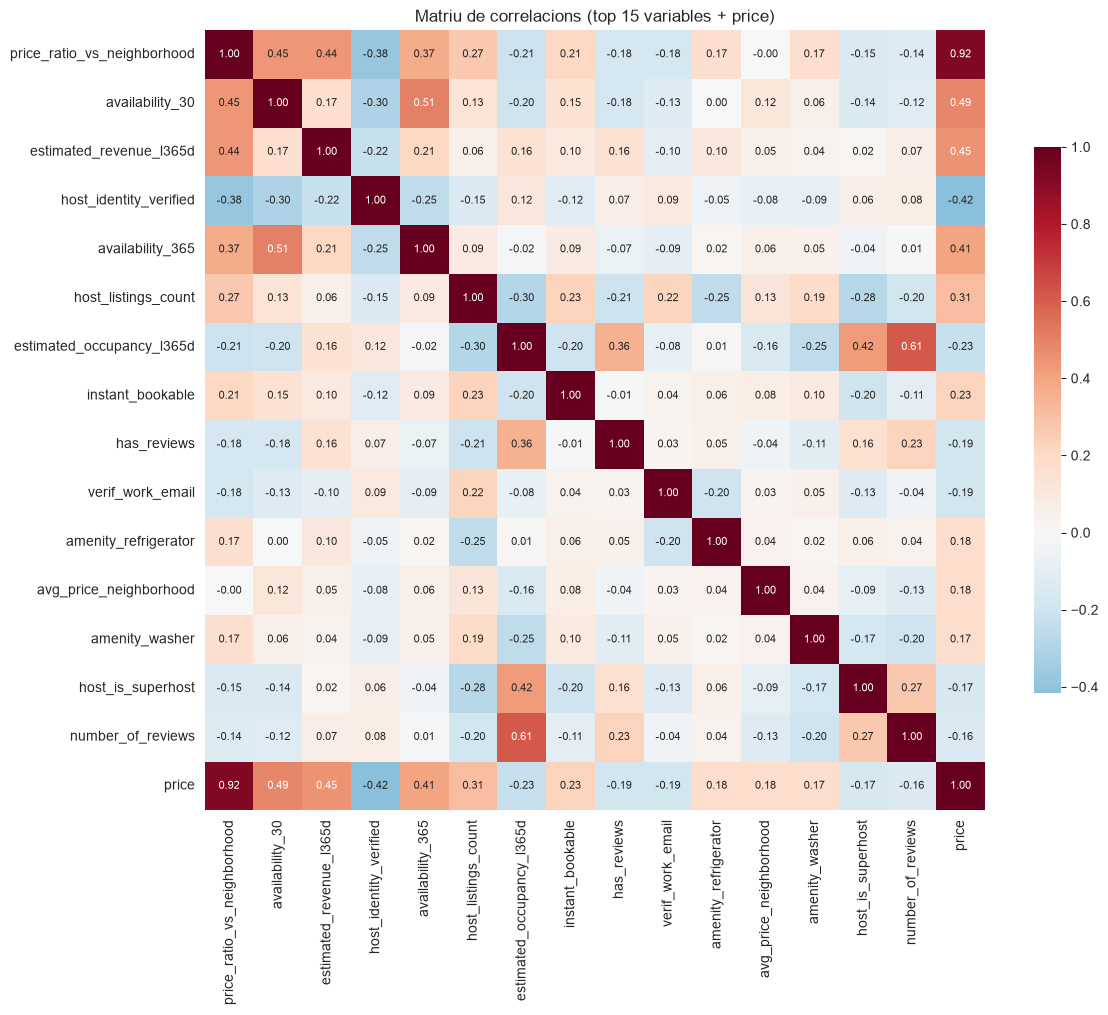

In [43]:
# Heatmap de les variables més correlacionades
top_features = corr_with_price.head(15).index.tolist() + ['price']
heatmap_data = corr_df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, cbar_kws={'shrink': 0.7},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Matriu de correlacions (top 15 variables + price)')
plt.tight_layout()
save_fig(fig, 'eda_12_correlation_heatmap.pdf')
plt.show()

In [44]:
# Detecció de multicol·linealitat forta (|r| > 0.9) entre predictors
corr_matrix = corr_df.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(c, r, upper.loc[r, c]) for c in upper.columns for r in upper.index if upper.loc[r, c] > 0.9]

if high_corr:
    print(f"Parells de variables amb correlació > 0.9: {len(high_corr)}")
    print()
    for c1, c2, val in sorted(high_corr, key=lambda x: -x[2]):
        print(f"   {val:.3f}  {c2}  <->  {c1}")
else:
    print("No s'han detectat parells amb correlació > 0.9")

Parells de variables amb correlació > 0.9: 7

   1.000  prop_shared_room  <->  room_Shared room
   0.976  room_Entire home/apt  <->  room_Private room
   0.976  dist_palma_center_km  <->  dist_airport_km
   0.947  dist_sea_km  <->  dist_sea_squared_km
   0.925  accommodates  <->  bedrooms
   0.920  longitude  <->  dist_palma_center_km
   0.917  price  <->  price_ratio_vs_neighborhood


### Observacions sobre les correlacions

#### *Data leakage*: `price_ratio_vs_neighborhood` (r = 0.917)

Aquesta variable **conté el preu mateix** dins la seva definició (és `price / avg_price_neighborhood` o similar). Té una correlació de 0.917 amb el target per construcció, no per poder predictiu. 

**Acció:** eliminar-la del dataset ABANS de dividir train/test. Igual per qualsevol variable que es calculi a partir de `price`.

#### Possibles *leaks*

`estimated_revenue_l365d` (r=0.449) i `estimated_occupancy_l365d` (r=-0.234) solen derivar de `price × nits ocupades`. Si `estimated_revenue` es va calcular amb el preu, també és *leaky*.



#### Discrepància Pearson vs Spearman (molt informativa!)

| Variable | Pearson | Spearman |
|---|---|---|
| `accommodates` | **no apareix al top 20** (<0.12) | **0.532** |
| `bedrooms` | no apareix | **0.521** |
| `bathrooms` | no apareix | **0.506** |
| `beds` | no apareix | **0.459** |
| `host_listings_count` | 0.306 | 0.401 |
| `number_of_reviews` | -0.155 | **-0.341** |
| `estimated_occupancy_l365d` | -0.234 | **-0.353** |

**Interpretació:** aquestes variables tenen una relació **monotònica però NO lineal** amb `price`. Pearson les infravalora.

**Implicacions:**
- **No les descartis** basant-te en Pearson.
- Aplicar `log1p(price)` probablement farà pujar molt les correlacions de Pearson d'aquestes variables.
- Modelar amb arbres (XGBoost, LightGBM, Random Forest) capturarà aquestes relacions millor que una regressió lineal amb aquestes variables en cru.

#### Multicol·linealitat forta detectada

Set parells amb |r| > 0.9. Alguns són problemàtics:

| Parell | r | Diagnòstic |
|---|---|---|
| `prop_shared_room`i `room_Shared room` | 1.000 | **Redundància perfecta** → elimina'n una |
| `room_Entire home/apt`  `room_Private room` | 0.976 | Dummy trap → elimina'n una |
| `dist_palma_center_km` i `dist_airport_km` | 0.976 | Molt alta → possiblement redundant |
| `dist_sea_km` i `dist_sea_squared_km` | 0.947 | Transformació redundant |
| `accommodates` i `bedrooms` | 0.925 | Esperable, però vigila en models lineals |
| `longitude` i `dist_palma_center_km` | 0.920 | Lògic si Palma és a una longitud fixa |
| `price` i `price_ratio_vs_neighborhood` | 0.917 | **Leak (ja comentat)** |

#### Features que SÍ que aporten

Un cop trets els leaks i redundàncies, les candidates són:

- **Mida de l'allotjament**: `accommodates`, `bedrooms`, `bathrooms`, `beds` (via Spearman)
- **Localització**: `dist_palma_center_km`, `dist_sea_km`, `avg_price_neighborhood`
- **Disponibilitat**: `availability_30`, `availability_365`
- **Tipus d'allotjament**: `prop_villa`, `room_Entire home/apt`
- **Perfil de l'amfitrió**: `host_listings_count`, `host_is_superhost`, `host_identity_verified`
- **Historial**: `number_of_reviews`, `number_of_reviews_ltm`, `has_reviews` (tots negatius → probable que reflecteixin "pisos baratos tenen més rotació")


#### 24 variables amb |r| < 0.05

No les eliminis automàticament. Revisa si:
- Són **binàries rares** (poca variància): poden tenir senyal en interaccions.
- Són **amenities individuals** (`amenity_X`): podrien tenir sentit combinades en un índex.
- Són **irrellevants reals**: llavors fora.


In [45]:
# Resum final del dataset per tancar l'EDA
print("=" * 60)
print("RESUM FINAL DE L'EDA")
print("=" * 60)
print(f"Files                : {df.shape[0]}")
print(f"Columnes             : {df.shape[1]}")
print("Variable objectiu    : price")
print(f"   Mediana (EUR/nit) : {df['price'].median():.2f}")
print(f"   Mitjana (EUR/nit) : {df['price'].mean():.2f}")
print(f"   Màxim   (EUR/nit) : {df['price'].max():.2f}")
print(f"Valors nuls          : {df.isnull().sum().sum()}")
print(f"Variables numèriques : {len(numeric_cols)}")
print(f"Variables booleanes  : {len(bool_cols)}")
print()
print(f"Figures generades a  : {OUTPUTS_DIR}")

RESUM FINAL DE L'EDA
Files                : 14342
Columnes             : 72
Variable objectiu    : price
   Mediana (EUR/nit) : 275.00
   Mitjana (EUR/nit) : 1557.74
   Màxim   (EUR/nit) : 10053.00
Valors nuls          : 5302
Variables numèriques : 36
Variables booleanes  : 31

Figures generades a  : ..\outputs
